In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [27]:
import os
os.environ["KERAS_BACKEND"] = "jax"

import bayesflow as bf

In [28]:
from simulators.benchmarks import DDM

In [29]:
num_obs = 200
num_train = 10000
num_val = 200
epochs = 100
batch_size = 32

### Workflow

In [41]:
simulator = DDM()

In [42]:
adapter = (
    bf.Adapter()
    .convert_dtype("float64", "float32")
    .drop(["decay"])
    .concatenate(["v", "a", "tau", "s_v", "s_tau"], axis=-1, into="inference_variables")
    .concatenate(["rts", "choices"], into="summary_variables")
)

In [43]:
summary_network = bf.networks.SetTransformer(summary_dim=16, seed_dim=128)
inference_network = bf.networks.FlowMatching()

In [44]:
workflow = bf.BasicWorkflow(
    inference_network=inference_network,
    summary_network=summary_network,
    simulator=simulator,
    adapter=adapter,
    checkpoint_filepath=f"../checkpoints/ddm_baseline_{num_obs}.ckpt",
)

Existing checkpoints can _not_ be restored/loaded using this workflow. Upon refitting, the checkpoints will be overwritten. To load the stored approximator from the checkpoint, use approximator = keras.saving.load_model(...)


In [45]:
train_set = workflow.simulate(num_train)
val_set = workflow.simulate(num_val)

In [52]:
history = workflow.fit_offline(
    data=train_set,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=val_set,
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - loss: 2.8047 - val_loss: 1.3215
Epoch 2/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 1.4855 - val_loss: 0.9500
Epoch 3/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 1.1692 - val_loss: 1.0252
Epoch 4/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - loss: 1.0524 - val_loss: 0.8813
Epoch 5/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - loss: 0.9913 - val_loss: 0.7893
Epoch 6/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - loss: 0.9619 - val_loss: 0.8525
Epoch 7/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 0.9196 - val_loss: 0.9290
Epoch 8/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 0.8807 - val_loss: 0.8616
Epoch 9/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - loss: 0.8518 - val_loss: 0.7563
Epoch 10/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - loss: 0.8273 - val_loss: 0.9011
Epoch 11/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step - loss: 0.7983 - val_loss: 0.8471
Epoch 12/100
313/313 ━

INFO:bayesflow:Training is now finished.
            You can find the trained approximator at '../checkpoints/ddm_baseline_200.ckpt/model.model.keras'.
            To load it, use approximator = keras.saving.load_model(...).


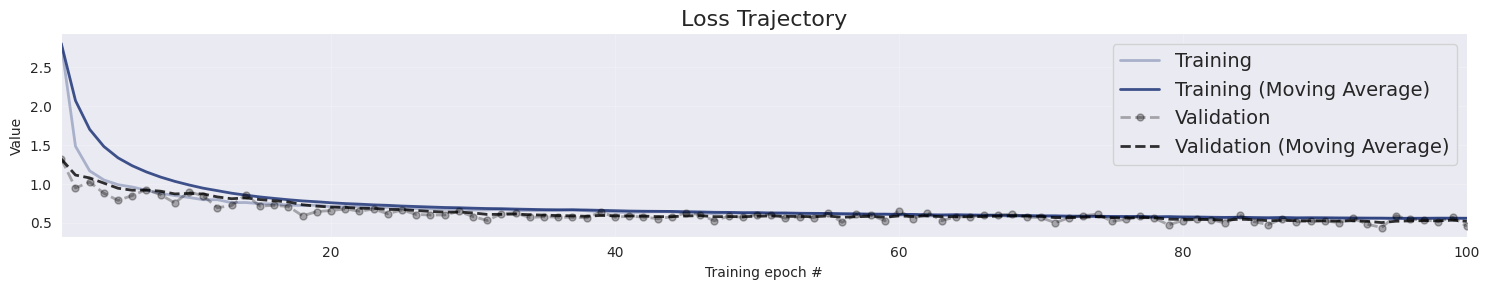

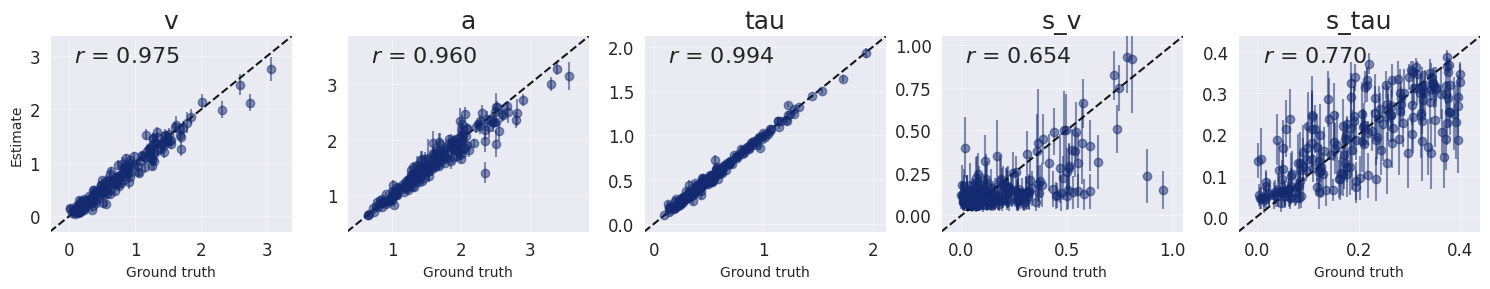

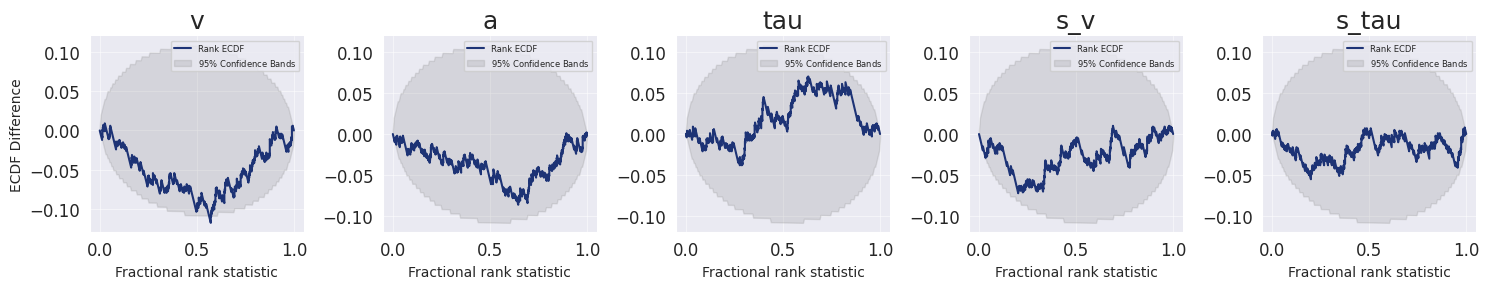

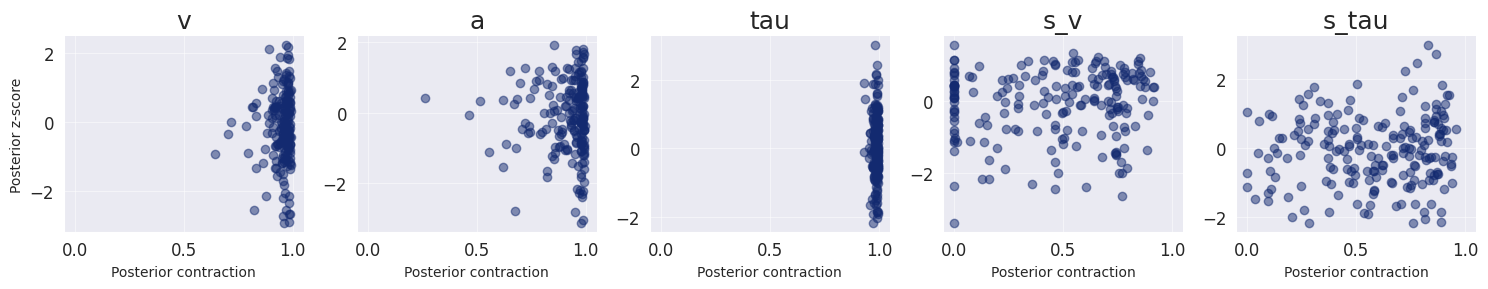

In [54]:
fig = workflow.plot_default_diagnostics(
    test_data=val_set,
    variable_names=["v", "a", "tau", "s_v", "s_tau"],
    num_samples=500,
    loss_kwargs={"figsize": (15, 3), "label_fontsize": 10},
    recovery_kwargs={"figsize": (15, 3), "label_fontsize": 10},
    calibration_ecdf_kwargs={"figsize": (15, 3), "legend_fontsize": 6, "difference": True, "label_fontsize": 10},
    z_score_contraction_kwargs={"figsize": (15, 3), "label_fontsize": 10}
)